In [ ]:
import pandas as pd

df = pd.read_csv('large_class.csv', sep=';')
df.head()

,file,project,version,loc,lloc,sloc,comments,multi,blank,cyclo,...,V,D,E,T,B,cbo,lcom,DIT,rfc,LargeClass
0,django/apps/config.py,django-5.2,5.2,274.0,128.0,163.0,55.0,19.0,35.0,60.0,...,736.589,5.414,3987.94,221.552,0.24553,22.0,5.0,0.0,22.0,0
1,django/apps/registry.py,django-5.2,5.2,437.0,203.0,209.0,56.0,88.0,79.0,76.0,...,706.016,6.844,4.831.796,268.433,0.235339,35.0,1.0,0.0,54.0,1
2,django/apps/__init__.py,django-5.2,5.2,4.0,3.0,3.0,0.0,0.0,1.0,0.0,...,0.0,0.000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
3,django/conf/global_settings.py,django-5.2,5.2,669.0,150.0,297.0,278.0,4.0,116.0,1.0,...,128.927,0.786,101.3,5.628,0.042976,0.0,0.0,0.0,0.0,0
4,django/conf/__init__.py,django-5.2,5.2,272.0,147.0,167.0,16.0,38.0,47.0,68.0,...,680.881,5.635,3.836.709,213.15,0.22696,44.0,3.0,1.0,22.0,1


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14599 entries, 0 to 14598
Data columns (total 28 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   file        14599 non-null  object 
 1   project     14599 non-null  object 
 2   version     14599 non-null  object 
 3   loc         14599 non-null  float64
 4   lloc        14599 non-null  float64
 5   sloc        14599 non-null  float64
 6   comments    14599 non-null  float64
 7   multi       14599 non-null  float64
 8   blank       14599 non-null  float64
 9   cyclo       14599 non-null  float64
 10  wmc         14599 non-null  float64
 11  η1          14599 non-null  float64
 12  η2          14599 non-null  float64
 13  N1          14599 non-null  float64
 14  N2          14599 non-null  float64
 15  η           14599 non-null  float64
 16  N           14599 non-null  float64
 17  N_hat       14599 non-null  object 
 18  V           14599 non-null  object 
 19  D           14599 non-nul

In [ ]:
df.isnull().sum()

,0
file,0
project,0
version,0
loc,0
lloc,0
sloc,0
comments,0
multi,0
blank,0
cyclo,0


In [ ]:
df['project'] = df['project'].str.replace(r'-.*$', '', regex=True)

In [ ]:
df

,file,project,version,loc,lloc,sloc,comments,multi,blank,cyclo,...,V,D,E,T,B,cbo,lcom,DIT,rfc,LargeClass
0,django/apps/config.py,django,5.2,274.0,128.0,163.0,55.0,19.0,35.0,60.0,...,736.589,5.414,3987.94,221.552,0.24553,22.0,5.0,0.0,22.0,0
1,django/apps/registry.py,django,5.2,437.0,203.0,209.0,56.0,88.0,79.0,76.0,...,706.016,6.844,4.831.796,268.433,0.235339,35.0,1.0,0.0,54.0,1
2,django/apps/__init__.py,django,5.2,4.0,3.0,3.0,0.0,0.0,1.0,0.0,...,0.0,0.000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
3,django/conf/global_settings.py,django,5.2,669.0,150.0,297.0,278.0,4.0,116.0,1.0,...,128.927,0.786,101.3,5.628,0.042976,0.0,0.0,0.0,0.0,0
4,django/conf/__init__.py,django,5.2,272.0,147.0,167.0,16.0,38.0,47.0,68.0,...,680.881,5.635,3.836.709,213.15,0.22696,44.0,3.0,1.0,22.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14594,scipy/cluster/tests/hierarchy_test_data.py,scipy,1.9.0,145.0,21.0,126.0,2.0,0.0,17.0,0.0,...,18.575,0.500,9.288,0.516,0.006192,0.0,0.0,0.0,0.0,0
14595,scipy/cluster/tests/test_disjoint_set.py,scipy,1.9.0,201.0,154.0,152.0,2.0,0.0,47.0,72.0,...,1.139.199,7.312,8.329.551,462.753,0.379733,0.0,0.0,0.0,0.0,0
14596,scipy/cluster/tests/test_hierarchy.py,scipy,1.9.0,1091.0,679.0,776.0,144.0,0.0,171.0,215.0,...,2.895.037,9.280,26.866.947,1.492.608,0.965012,141.0,11.0,0.0,20.0,1
14597,scipy/cluster/tests/test_vq.py,scipy,1.9.0,336.0,203.0,262.0,22.0,0.0,57.0,45.0,...,3.818.648,3.346,12.778.549,709.919,1.272.883,39.0,15.0,0.0,32.0,1


In [ ]:
df['LargeClass'].unique()

array([0, 1])

In [ ]:
df.isnull().sum()

,0
file,0
project,0
version,0
loc,0
lloc,0
sloc,0
comments,0
multi,0
blank,0
cyclo,0


# **SPLIT DATA**

In [ ]:
from sklearn.model_selection import train_test_split

# Simpan metadata
meta = df[["file", "version", "project"]]

# Pisahkan fitur dan label
X = df.drop(columns=["file", "version", "project","LargeClass"])
y = df["LargeClass"]

X_train, X_test, y_train, y_test, meta_train, meta_test = train_test_split(
    X, y, meta, test_size=0.2, random_state=42, shuffle=True, stratify=y
)

forbidden = ["loc", "DIT", "rfc"]
X_train = X_train.drop(columns=forbidden)
X_test  = X_test.drop(columns=forbidden)

print("Fitur final:", X_train.columns.tolist())

Fitur final: ['lloc', 'sloc', 'comments', 'multi', 'blank', 'cyclo', 'wmc', 'η1', 'η2', 'N1', 'N2', 'η', 'N', 'N_hat', 'V', 'D', 'E', 'T', 'B', 'cbo', 'lcom']


# **FEATURE SCALING**

In [ ]:
import numpy as np
import pandas as pd
from sklearn.base import BaseEstimator, TransformerMixin

class ModifiedZScoreScaler(BaseEstimator, TransformerMixin):
    """
    Modified Z-score scaling (median & MAD).
    Cocok untuk data skewed / outlier-heavy.
    """
    def fit(self, X, y=None):
        self.medians_ = X.median()
        self.mads_ = (np.abs(X - self.medians_)).median()
        self.mads_ = self.mads_.replace(0, 1e-9)
        return self

    def transform(self, X):
        return 0.6745 * (X - self.medians_) / self.mads_

# **FEATURE SELECTION**

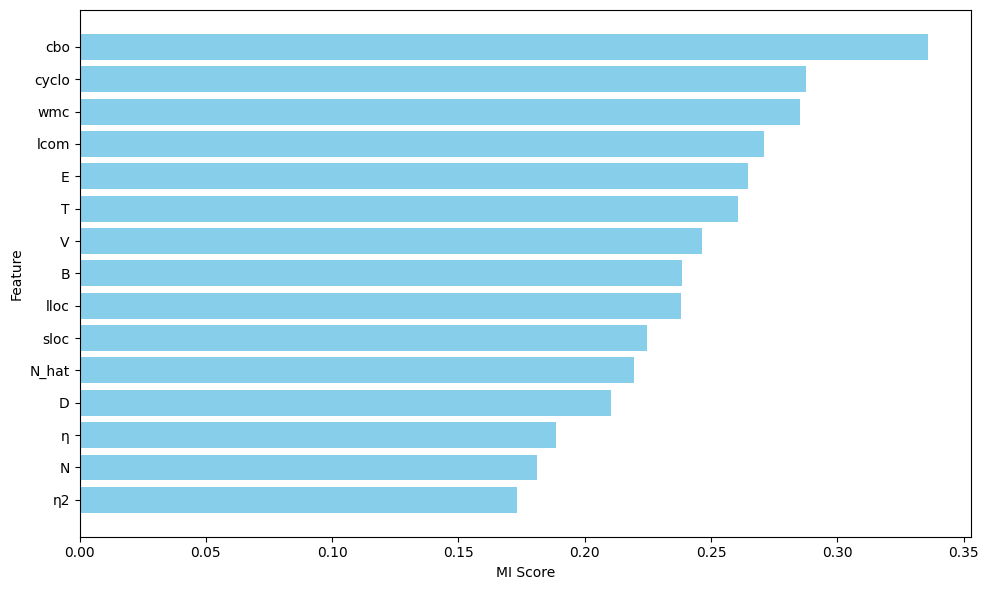

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.feature_selection import mutual_info_classif
import numpy as np

def select_topk_features_MI(X, y, k):
    """
    Feature selection menggunakan Mutual Information.
    Mengambil k fitur teratas berdasarkan skor MI.
    """
    scores = mutual_info_classif(X, y, random_state=42)
    mi_series = pd.Series(scores, index=X.columns)
    selected = mi_series.nlargest(k).index.tolist()
    return selected, scores

# --- FIX START ---
# Identify columns that are object type but should be numeric
object_cols = X_train.select_dtypes(include=['object']).columns

for col in object_cols:
    if col in ['N_hat', 'V', 'E', 'T', 'B']:
        # Replace '.' as thousands separator, then ',' as decimal separator, then convert to float
        X_train[col] = X_train[col].astype(str).str.replace('.', '', regex=False).str.replace(',', '.', regex=False).astype(float)
        X_test[col] = X_test[col].astype(str).str.replace('.', '', regex=False).str.replace(',', '.', regex=False).astype(float)
# --- FIX END ---

# Misal menggunakan top-k MI
selected_features, scores = select_topk_features_MI(X_train, y_train, k=15)

# Buat dataframe untuk plotting
mi_df = pd.DataFrame({
    "feature": X_train.columns,
    "mi_score": scores
}).sort_values("mi_score", ascending=True)

# Ambil data fitur yang terpilih
mi_selected_df = mi_df[mi_df["feature"].isin(selected_features)]

# Plot
plt.figure(figsize=(10, 6))
plt.barh(mi_selected_df["feature"], mi_selected_df["mi_score"], color='skyblue')
# plt.title("Top-15 Features Based on Mutual Information")
plt.xlabel("MI Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

**MENGAMBIL TRAIN DAN TEST**

In [ ]:
# top-k fitur dari train
X_train_topk = X_train[selected_features]
X_test_topk = X_test[selected_features]

# Scaling

scaler = ModifiedZScoreScaler()
X_train_scaled = scaler.fit_transform(X_train_topk)
X_test_scaled = scaler.transform(X_test_topk)

# DataFrame

X_train_final = pd.DataFrame(X_train_scaled, columns=selected_features)
X_test_final = pd.DataFrame(X_test_scaled, columns=selected_features)

# Gabung target dan metadata

train_final = pd.concat([meta_train.reset_index(drop=True),
                         X_train_final.reset_index(drop=True),
                         y_train.reset_index(drop=True)], axis=1)

test_final = pd.concat([meta_test.reset_index(drop=True),
                        X_test_final.reset_index(drop=True),
                        y_test.reset_index(drop=True)], axis=1)


train_final.to_csv("train_largeclass.csv", index=False)
test_final.to_csv("test_largeclass.csv", index=False)

print("✅ Dataset train & test dengan metadata berhasil disimpan!")

✅ Dataset train & test dengan metadata berhasil disimpan!


In [ ]:
dc = pd.read_csv('train_largeclass.csv')
dc.head()

,file,version,project,cbo,cyclo,wmc,lcom,E,T,V,B,lloc,sloc,N_hat,D,η,N,η2,LargeClass
0,numpy/distutils/fcompiler/environment.py,2.1.0,numpy,5.396000e+09,1.854875,1.854875,6.745000e+08,3.624536,3.129618,1.834431,1.686656,0.616686,0.369369,1.953687,0.532125,0.632344,0.562083,0.674500,0
1,tutorials/advanced/path_tutorial.py,3.4.0,matplotlib,0.000000e+00,-0.674500,-0.674500,0.000000e+00,0.753407,0.589008,0.809405,0.722008,0.578143,0.481786,0.293640,0.003139,-0.042156,0.252937,0.000000,0
2,django/utils/translation/reloader.py,4.2,django,0.000000e+00,0.000000,0.000000,0.000000e+00,-0.672821,-0.673014,-0.671738,-0.674240,-0.346886,-0.417548,-0.342863,-0.246518,-0.337250,-0.449667,-0.393458,0
3,numpy/f2py/tests/test_callback.py,2.1.0,numpy,1.551350e+10,4.299938,4.299938,1.349000e+09,10.353583,9.084024,7.243748,6.777333,2.351114,2.039560,6.151195,0.306435,1.897031,2.585583,2.473167,1
4,scipy/signal/_short_time_fft.py,1.13.0,scipy,3.102700e+10,13.068437,13.068437,4.721500e+09,594.637043,526.105841,93.495439,87.948470,8.267443,6.552286,76.100983,3.777371,18.085031,25.462375,23.101625,1


LargeClass
0    7981
1    3698
Name: count, dtype: int64
LargeClass
0    0.683363
1    0.316637
Name: proportion, dtype: float64


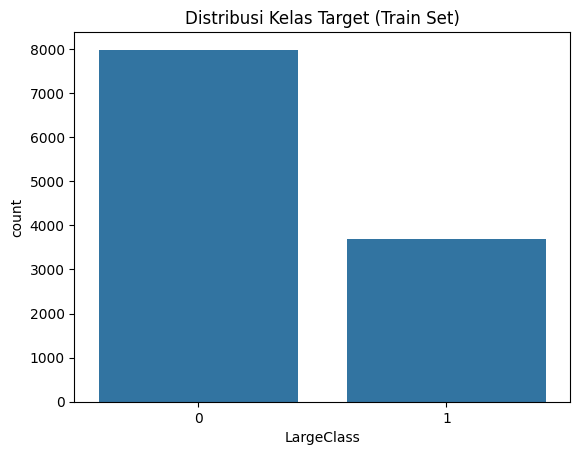

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Jumlah tiap kelas
print(y_train.value_counts())

# Proporsi tiap kelas
print(y_train.value_counts(normalize=True))

# Visualisasi distribusi target
sns.countplot(x=y_train)
plt.title("Distribusi Kelas Target (Train Set)")
plt.show()

# **MODELING**

**RANDOM FOREST**

In [ ]:
import time
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, matthews_corrcoef
import numpy as np

n_estimators_list = [100, 200, 300]

rskf = RepeatedStratifiedKFold(n_splits=5, n_repeats=5, random_state=42)

# Initialize fold_metrics for plotting outside the main loop
fold_metrics = {}

# Untuk menyimpan hasil akhir per n_estimators
mean_acc_results = []
mean_mcc_results = []

for n in n_estimators_list:

    print("\n\n======================")
    print(f"   n_estimators = {n}")
    print("======================")

    acc_all = []
    mcc_all = []
    train_time_all = []
    predict_time_all = []
    fold_counter = 1

    # Initialize entry for current n in fold_metrics
    fold_metrics[n] = {
        "acc": [],
        "mcc": [],
        "train_time": [],
        "pred_time": []
    }

    # === CV berjalan untuk setiap n_estimators ===
    for train_idx, test_idx in rskf.split(X_train, y_train):

        # === Ambil fold ===
        X_train_fold = X_train.iloc[train_idx].copy()
        X_test_fold  = X_train.iloc[test_idx].copy()
        y_train_fold = y_train.iloc[train_idx]
        y_test_fold  = y_train.iloc[test_idx]

        # === Feature Selection ===
        selected_features, scores = select_topk_features_MI(X_train_fold, y_train_fold, k=15)
        X_train_fs = X_train_fold[selected_features]
        X_test_fs  = X_test_fold[selected_features]

        # === Scaling ===
        scaler = ModifiedZScoreScaler()
        X_train_scaled = scaler.fit_transform(X_train_fs)
        X_test_scaled  = scaler.transform(X_test_fs)

        # === Model ===
        model = RandomForestClassifier(
            n_estimators=n,
            max_depth=7,
            class_weight='balanced',
            random_state=42,
            n_jobs=-1
        )

        # === Timing Training ===
        start_train = time.time()
        model.fit(X_train_scaled, y_train_fold)
        train_time = time.time() - start_train

        # === Timing Predict ===
        start_pred = time.time()
        y_pred = model.predict(X_test_scaled)
        pred_time = time.time() - start_pred

        # === Evaluasi ===
        acc = accuracy_score(y_test_fold, y_pred)
        mcc = matthews_corrcoef(y_test_fold, y_pred)

        acc_all.append(acc)
        mcc_all.append(mcc)
        train_time_all.append(train_time)
        predict_time_all.append(pred_time)

        # Store per-fold metrics in fold_metrics
        fold_metrics[n]["acc"].append(acc)
        fold_metrics[n]["mcc"].append(mcc)
        fold_metrics[n]["train_time"].append(train_time)
        fold_metrics[n]["pred_time"].append(pred_time)

        print(f"\n===== Fold {fold_counter} ====")
        print("Selected features:", list(selected_features))
        print(f"Accuracy: {acc:.5f}")
        print(f"MCC: {mcc:.5f}")
        print(f"Training Time:  {train_time:.5f} sec")
        print(f"Prediksi Time:  {pred_time:.5f} sec")
        fold_counter += 1

    # === Hasil per konfigurasi n_estimators ===
    mean_acc_results.append(np.mean(acc_all))
    mean_mcc_results.append(np.mean(mcc_all))
    mean_train = np.mean(train_time_all)
    mean_pred = np.mean(predict_time_all)

    print("\n>>> RESULT for n_estimators =", n)
    print(f"Mean Accuracy: {np.mean(acc_all):.5f}")
    print(f"Mean MCC: {np.mean(mcc_all):.5f}")
    print(f"Mean Train Time:    {mean_train:.5f} sec")
    print(f"Mean Predict Time:  {mean_pred:.5f} sec")



   n_estimators = 100

===== Fold 1 ====
Selected features: ['cbo', 'cyclo', 'wmc', 'lcom', 'lloc', 'E', 'T', 'V', 'B', 'sloc', 'N_hat', 'D', 'N', 'η', 'N2']
Accuracy: 0.91053
MCC: 0.82189
Training Time:  0.93859 sec
Prediksi Time:  0.04626 sec

===== Fold 2 ====
Selected features: ['cbo', 'wmc', 'cyclo', 'lcom', 'lloc', 'E', 'T', 'V', 'B', 'sloc', 'N_hat', 'D', 'η', 'blank', 'N2']
Accuracy: 0.90668
MCC: 0.81624
Training Time:  1.27412 sec
Prediksi Time:  0.04584 sec

===== Fold 3 ====
Selected features: ['cbo', 'cyclo', 'wmc', 'lcom', 'lloc', 'E', 'T', 'V', 'B', 'sloc', 'N_hat', 'D', 'blank', 'N', 'N2']
Accuracy: 0.91182
MCC: 0.82418
Training Time:  0.79601 sec
Prediksi Time:  0.03485 sec

===== Fold 4 ====
Selected features: ['cbo', 'wmc', 'cyclo', 'lcom', 'lloc', 'E', 'T', 'V', 'B', 'sloc', 'N_hat', 'D', 'blank', 'η', 'N']
Accuracy: 0.90325
MCC: 0.81091
Training Time:  0.76335 sec
Prediksi Time:  0.03494 sec

===== Fold 5 ====
Selected features: ['cbo', 'cyclo', 'wmc', 'lcom', 'E'

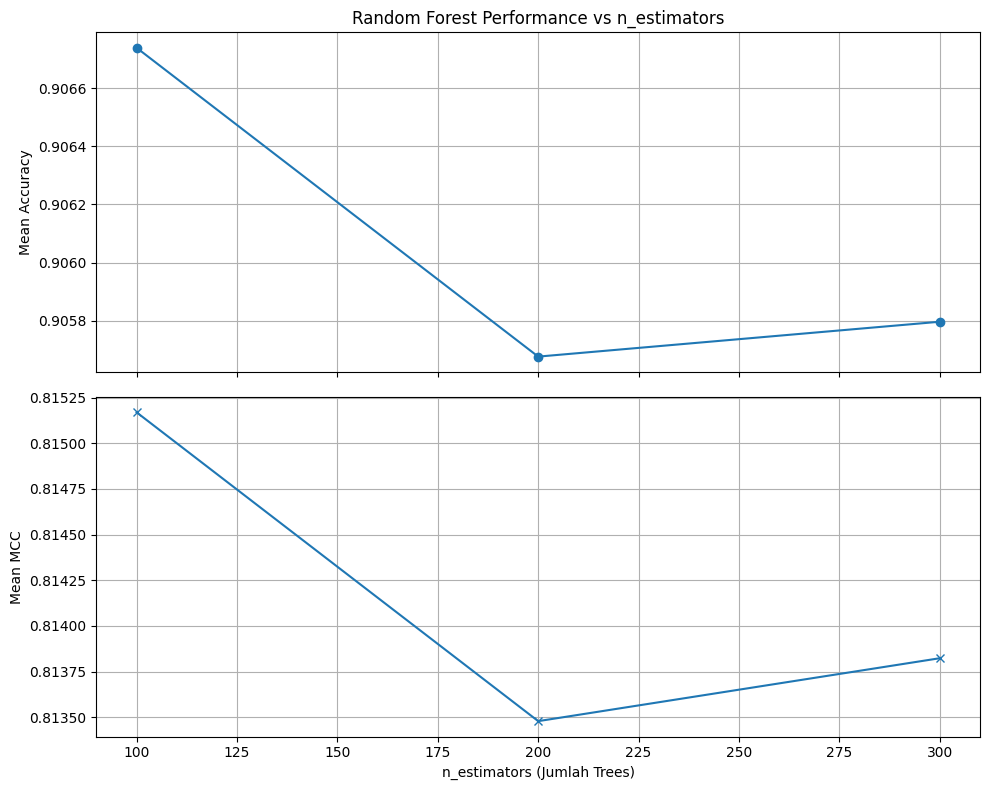

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# Accuracy
axes[0].plot(n_estimators_list, mean_acc_results, marker='o')
axes[0].set_ylabel('Mean Accuracy')
axes[0].set_title('Random Forest Performance vs n_estimators')
axes[0].grid(True)

#  MCC
axes[1].plot(n_estimators_list, mean_mcc_results, marker='x')
axes[1].set_xlabel('n_estimators (Jumlah Trees)')
axes[1].set_ylabel('Mean MCC')
axes[1].grid(True)

plt.tight_layout()
plt.show()

## **KNN**

In [ ]:
import time
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, matthews_corrcoef
import numpy as np

n_neighbors_list = [1, 3, 5, 7, 9, 11]

rskf = RepeatedStratifiedKFold(n_splits=5, n_repeats=5, random_state=42)

# Final results
mean_acc_knn = []
mean_mcc_knn = []
mean_train_knn = []
mean_pred_knn = []

for k in n_neighbors_list:

    print("\n\n======================")
    print(f"        K = {k}")
    print("======================")

    acc_all = []
    mcc_all = []
    train_time_all = []
    predict_time_all = []

    fold_counter = 1

    for train_idx, test_idx in rskf.split(X_train, y_train):

        X_train_fold = X_train.iloc[train_idx].copy()
        X_test_fold  = X_train.iloc[test_idx].copy()
        y_train_fold = y_train.iloc[train_idx]
        y_test_fold  = y_train.iloc[test_idx]

        selected_features, scores = select_topk_features_MI(X_train_fold, y_train_fold, k=15)
        X_train_fs = X_train_fold[selected_features]
        X_test_fs  = X_test_fold[selected_features]

        scaler = ModifiedZScoreScaler()
        X_train_scaled = scaler.fit_transform(X_train_fs)
        X_test_scaled  = scaler.transform(X_test_fs)

        model = KNeighborsClassifier(
            n_neighbors=k,
            weights='distance',
            p=2
        )

        # Training time
        start_train = time.time()
        model.fit(X_train_scaled, y_train_fold)
        train_time = time.time() - start_train

        # Prediction time
        start_pred = time.time()
        y_pred = model.predict(X_test_scaled)
        pred_time = time.time() - start_pred

        acc = accuracy_score(y_test_fold, y_pred)
        mcc = matthews_corrcoef(y_test_fold, y_pred)

        acc_all.append(acc)
        mcc_all.append(mcc)
        train_time_all.append(train_time)
        predict_time_all.append(pred_time)

        print(f"\n===== Fold {fold_counter} =====")
        print("Selected features:", list(selected_features))
        print(f"Accuracy: {acc:.5f}")
        print(f"MCC: {mcc:.5f}")
        print(f"Training Time:  {train_time:.5f} sec")
        print(f"Prediction Time: {pred_time:.5f} sec")
        fold_counter += 1

    # Store mean results
    mean_acc_knn.append(np.mean(acc_all))
    mean_mcc_knn.append(np.mean(mcc_all))
    mean_train_knn.append(np.mean(train_time_all))
    mean_pred_knn.append(np.mean(predict_time_all))

    print("\n>>> RESULT for K =", k)
    print(f"Mean Accuracy: {np.mean(acc_all):.5f}")
    print(f"Mean MCC: {np.mean(mcc_all):.5f}")
    print(f"Mean Train Time:    {np.mean(train_time_all):.5f} sec")
    print(f"Mean Predict Time:  {np.mean(predict_time_all):.5f} sec")



        K = 1

===== Fold 1 =====
Selected features: ['cbo', 'cyclo', 'wmc', 'lcom', 'lloc', 'E', 'T', 'V', 'B', 'sloc', 'N_hat', 'D', 'N', 'η', 'N2']
Accuracy: 0.96490
MCC: 0.91849
Training Time:  0.01826 sec
Prediction Time: 0.06025 sec

===== Fold 2 =====
Selected features: ['cbo', 'wmc', 'cyclo', 'lcom', 'lloc', 'E', 'T', 'V', 'B', 'sloc', 'N_hat', 'D', 'η', 'blank', 'N2']
Accuracy: 0.95933
MCC: 0.90573
Training Time:  0.01826 sec
Prediction Time: 0.07494 sec

===== Fold 3 =====
Selected features: ['cbo', 'cyclo', 'wmc', 'lcom', 'lloc', 'E', 'T', 'V', 'B', 'sloc', 'N_hat', 'D', 'blank', 'N', 'N2']
Accuracy: 0.95933
MCC: 0.90589
Training Time:  0.01809 sec
Prediction Time: 0.05969 sec

===== Fold 4 =====
Selected features: ['cbo', 'wmc', 'cyclo', 'lcom', 'lloc', 'E', 'T', 'V', 'B', 'sloc', 'N_hat', 'D', 'blank', 'η', 'N']
Accuracy: 0.95291
MCC: 0.89099
Training Time:  0.01830 sec
Prediction Time: 0.05812 sec

===== Fold 5 =====
Selected features: ['cbo', 'cyclo', 'wmc', 'lcom', 'E

Itepretasi:

Nilai K yang paling baik adalah K = 9, karena pada dataset yang bersifat imbalance, K = 9 memberikan nilai MCC yang hampir setara dengan K = 11, namun dengan waktu prediksi yang lebih efisien, sehingga menghasilkan keseimbangan terbaik antara kualitas klasifikasi dan efisiensi komputasi.

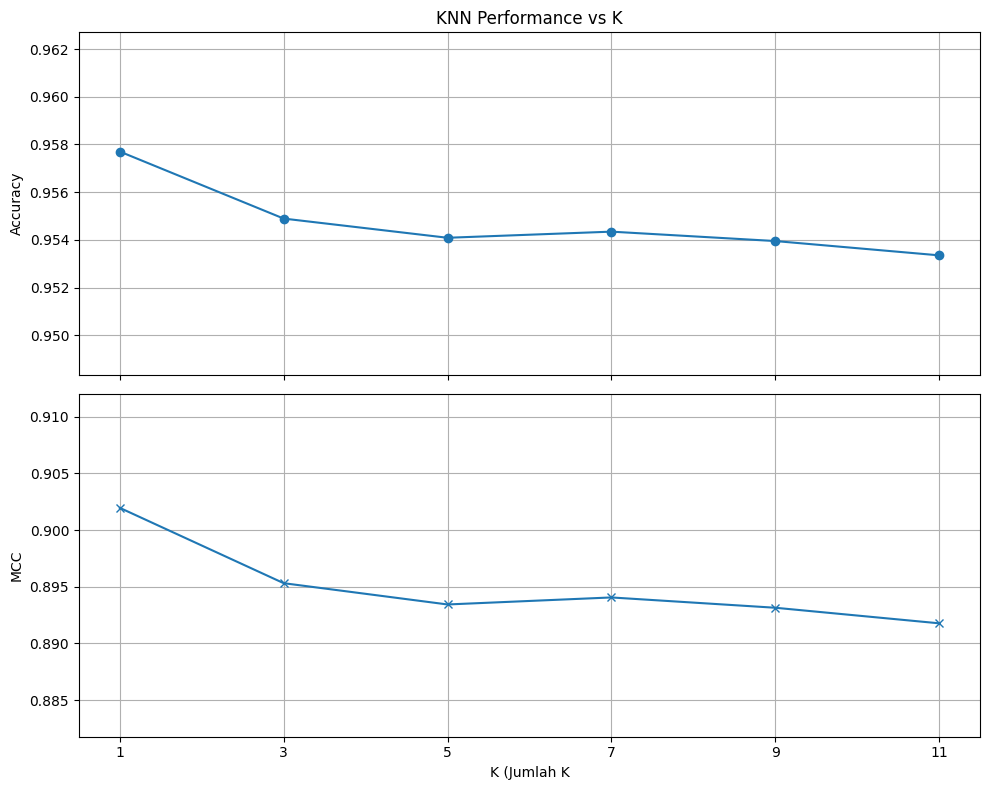

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# Accuracy
axes[0].plot(n_neighbors_list, mean_acc_knn, marker='o')
axes[0].set_ylabel("Accuracy")
axes[0].set_title("KNN Performance vs K")
axes[0].grid(True)
axes[0].set_ylim(min(mean_acc_knn)-0.005, max(mean_acc_knn)+0.005)

#  MCC
axes[1].plot(n_neighbors_list, mean_mcc_knn, marker='x')
axes[1].set_xlabel("K (Jumlah K")
axes[1].set_ylabel("MCC")
axes[1].grid(True)
axes[1].set_ylim(min(mean_mcc_knn)-0.01, max(mean_mcc_knn)+0.01)

# Set X-ticks sesuai angka K
plt.xticks(n_neighbors_list)

plt.tight_layout()
plt.show()

# **AMBIL MODEL**

In [ ]:
class ModifiedZScoreScaler:
    def fit(self, X):
        import numpy as np
        self.median_ = np.median(X, axis=0)
        self.mad_ = np.median(np.abs(X - self.median_), axis=0)
        self.mad_[self.mad_ == 0] = 1e-9
        return self

    def transform(self, X):
        return 0.6745 * (X - self.median_) / self.mad_

    def fit_transform(self, X):
        return self.fit(X).transform(X)

In [ ]:
scaler = ModifiedZScoreScaler()
X_train_scaled = scaler.fit_transform(X_train_fs)

print("AFTER FIT:", hasattr(scaler, "median_"), hasattr(scaler, "mad_"))

AFTER FIT: True True


In [ ]:
from joblib import dump
from sklearn.neighbors import KNeighborsClassifier


# FEATURE SELECTION
selected_features, _ = select_topk_features_MI(X_train, y_train, k=15)
X_train_fs = X_train[selected_features]

# SCALING
scaler = ModifiedZScoreScaler()
X_train_scaled = scaler.fit_transform(X_train_fs)

# === MODEL ===
final_model = KNeighborsClassifier(
    n_neighbors= 9,
    weights='distance',
    p=2
)

model.fit(X_train_scaled, y_train)

# === BUNDLE VALID ===
bundle = {
    "model": model,
    "preprocessing": {
        "scaler": scaler,
        "features": selected_features
    },
    "meta": {
        "model_type": "KNN",
        "scaler": "ModifiedZScore"
    }
}

dump(bundle, "knn_largeclass_9.joblib")
print("Model + scaler berhasil disimpan dengan BENAR")

Model + scaler berhasil disimpan dengan BENAR


In [ ]:
from joblib import load

bundle_check = load("knn_largeclass_9.joblib")
scaler_check = bundle_check["preprocessing"]["scaler"]

print(hasattr(scaler_check, "median_"))
print(hasattr(scaler_check, "mad_"))

True
True


# **LOGISTIC REGRESION**

In [ ]:
import time
import numpy as np
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, matthews_corrcoef

C_list = [0.001, 0.01, 0.1, 1, 10, 100]

mean_acc_lr = []
mean_mcc_lr = []

rskf = RepeatedStratifiedKFold(n_splits=5, n_repeats=5, random_state=42)

print("\n===============================")
print("  LOGISTIC REGRESSION EVALUATION")
print("===============================\n")

for C in C_list:

    print("\n\n=====================")
    print(f"        C = {C}")
    print("=====================")

    acc_all = []
    mcc_all = []
    train_time_all = []
    predict_time_all = []
    fold_counter = 1

    for train_idx, test_idx in rskf.split(X_train, y_train):

        X_train_fold = X_train.iloc[train_idx].copy()
        X_test_fold  = X_train.iloc[test_idx].copy()
        y_train_fold = y_train.iloc[train_idx]
        y_test_fold  = y_train.iloc[test_idx]

        # Feature Selection
        selected_features, scores = select_topk_features_MI(X_train_fold, y_train_fold, k=15)
        X_train_fs = X_train_fold[selected_features]
        X_test_fs  = X_test_fold[selected_features]

        # Scaling
        scaler = ModifiedZScoreScaler()
        X_train_scaled = scaler.fit_transform(X_train_fs)
        X_test_scaled  = scaler.transform(X_test_fs)

        # Model
        model = LogisticRegression(C=C, max_iter=3000, solver='lbfgs')

        start_train = time.time()
        model.fit(X_train_scaled, y_train_fold)
        train_time = time.time() - start_train

        start_pred = time.time()
        y_pred = model.predict(X_test_scaled)
        pred_time = time.time() - start_pred

        acc = accuracy_score(y_test_fold, y_pred)
        mcc = matthews_corrcoef(y_test_fold, y_pred)

        acc_all.append(acc)
        mcc_all.append(mcc)
        train_time_all.append(train_time)
        predict_time_all.append(pred_time)

        print(f"\n===== Fold {fold_counter} ====")
        print("Selected features:", list(selected_features))
        print(f"Accuracy: {acc:.5f}")
        print(f"MCC: {mcc:.5f}")
        print(f"Training Time:  {train_time:.5f} sec")
        print(f"Prediction Time:{pred_time:.5f} sec")

        fold_counter += 1

    # Simpan hasil rata-rata
    mean_acc_lr.append(np.mean(acc_all))
    mean_mcc_lr.append(np.mean(mcc_all))

    print("\n>>> RESULT for C =", C)
    print(f"Mean Accuracy: {np.mean(acc_all):.5f}")
    print(f"Mean MCC: {np.mean(mcc_all):.5f}")
    print(f"Mean Train Time:    {np.mean(train_time_all):.5f} sec")
    print(f"Mean Predict Time:  {np.mean(predict_time_all):.5f} sec")


  LOGISTIC REGRESSION EVALUATION



        C = 0.001

===== Fold 1 ====
Selected features: ['cbo', 'cyclo', 'wmc', 'lcom', 'lloc', 'E', 'T', 'V', 'B', 'sloc', 'N_hat', 'D', 'N', 'η', 'N2']
Accuracy: 0.69863
MCC: 0.53513
Training Time:  0.04007 sec
Prediction Time:0.00172 sec

===== Fold 2 ====
Selected features: ['cbo', 'wmc', 'cyclo', 'lcom', 'lloc', 'E', 'T', 'V', 'B', 'sloc', 'N_hat', 'D', 'η', 'blank', 'N2']
Accuracy: 0.69307
MCC: 0.52889
Training Time:  0.02486 sec
Prediction Time:0.00161 sec

===== Fold 3 ====
Selected features: ['cbo', 'cyclo', 'wmc', 'lcom', 'lloc', 'E', 'T', 'V', 'B', 'sloc', 'N_hat', 'D', 'blank', 'N', 'N2']
Accuracy: 0.69692
MCC: 0.53324
Training Time:  0.02367 sec
Prediction Time:0.00167 sec

===== Fold 4 ====
Selected features: ['cbo', 'wmc', 'cyclo', 'lcom', 'lloc', 'E', 'T', 'V', 'B', 'sloc', 'N_hat', 'D', 'blank', 'η', 'N']
Accuracy: 0.70462
MCC: 0.54200
Training Time:  0.02700 sec
Prediction Time:0.00166 sec

===== Fold 5 ====
Selected features: ['cb

Itepretasi:

Pemilihan parameter C dilakukan dengan mempertimbangkan nilai MCC sebagai metrik utama karena dataset bersifat tidak seimbang. Berdasarkan hasil eksperimen, C = 10 memberikan performa yang setara dengan nilai C yang lebih besar, namun dengan waktu prediksi yang lebih efisien, sehingga dipilih sebagai parameter optimal.

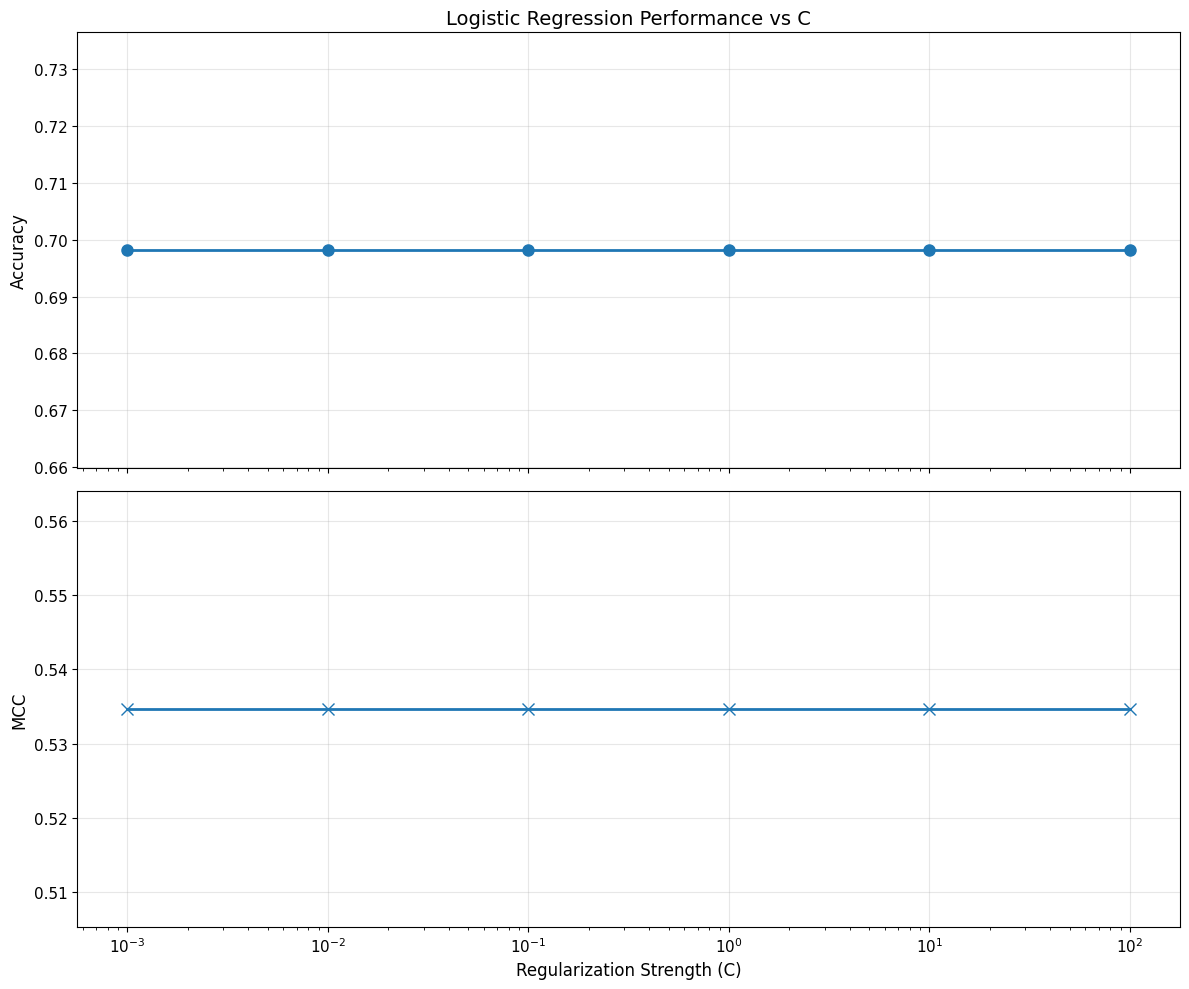

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

# Accuracy
axes[0].plot(C_list, mean_acc_lr, marker='o', linewidth=2, markersize=8)
axes[0].set_xscale('log')
axes[0].set_ylabel("Accuracy", fontsize=12)
axes[0].set_title("Logistic Regression Performance vs C", fontsize=14)
axes[0].grid(True, alpha=0.3)
axes[0].tick_params(axis='both', labelsize=11)

# MCC
axes[1].plot(C_list, mean_mcc_lr, marker='x', linewidth=2, markersize=8)
axes[1].set_xscale('log')
axes[1].set_xlabel("Regularization Strength (C)", fontsize=12)
axes[1].set_ylabel("MCC", fontsize=12)
axes[1].grid(True, alpha=0.3)
axes[1].tick_params(axis='both', labelsize=11)

# Set X-ticks agar sesuai angka
plt.xticks(C_list)

plt.tight_layout()
plt.show()

In [ ]:
import time
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, matthews_corrcoef, confusion_matrix
import numpy as np

# Hyperparameter MLP
hidden_layer_sizes_list = [4, 8, 16, 32, 64, 100]

# Untuk menyimpan hasil mean
mean_acc_mlp = []
mean_mcc_mlp = []
train_time_all = []
predict_time_all = []
fold_counter = 1

# Repeated CV
rskf = RepeatedStratifiedKFold(n_splits=5, n_repeats=5, random_state=42)

print("\n===============================")
print("      MLP CLASSIFIER EVALUATION")
print("===============================\n")

for h in hidden_layer_sizes_list:

    print("\n\n======================")
    print(f"  Hidden Layer = {h}")
    print("======================")

    acc_all = []
    mcc_all = []
    train_time_all = []
    predict_time_all = []

    fold_counter = 1

    # ==== Cross Validation ====
    for train_idx, test_idx in rskf.split(X_train, y_train):

        # Ambil fold
        X_train_fold = X_train.iloc[train_idx].copy()
        X_test_fold  = X_train.iloc[test_idx].copy()
        y_train_fold = y_train.iloc[train_idx]
        y_test_fold  = y_train.iloc[test_idx]

        # Feature selection
        selected_features, scores = select_topk_features_MI(X_train_fold, y_train_fold, k=15)
        X_train_fs = X_train_fold[selected_features]
        X_test_fs  = X_test_fold[selected_features]

        # Scaling per fold
        scaler = ModifiedZScoreScaler()
        X_train_scaled = scaler.fit_transform(X_train_fs)
        X_test_scaled  = scaler.transform(X_test_fs)

        # ==== MLP Model ====
        model = MLPClassifier(
            hidden_layer_sizes=(h,),   # satu hidden layer
            activation='relu',
            solver='adam',
            max_iter=2000,
            random_state=42
        )

        # === Timing Training ===
        start_train = time.time()
        model.fit(X_train_scaled, y_train_fold)
        train_time = time.time() - start_train

        # === Timing Predict ===
        start_pred = time.time()
        y_pred = model.predict(X_test_scaled)
        pred_time = time.time() - start_pred

        model.fit(X_train_scaled, y_train_fold)
        y_pred = model.predict(X_test_scaled)

        # === Evaluasi ===
        acc = accuracy_score(y_test_fold, y_pred)
        mcc = matthews_corrcoef(y_test_fold, y_pred)

        acc_all.append(acc)
        mcc_all.append(mcc)
        train_time_all.append(train_time)
        predict_time_all.append(pred_time)

        print(f"\n===== Fold {fold_counter} ====")
        print("Selected features:", list(selected_features))
        print(f"Accuracy: {acc:.5f}")
        print(f"MCC: {mcc:.5f}")
        print(f"Training Time:  {train_time:.5f} sec")
        print(f"Prediksi Time:  {pred_time:.5f} sec")
        fold_counter += 1

    # === Hasil per konfigurasi Hidden Layer ===
    mean_acc_mlp.append(np.mean(acc_all))
    mean_mcc_mlp.append(np.mean(mcc_all))
    mean_train = np.mean(train_time_all)
    mean_pred = np.mean(predict_time_all)

    print("\n>>> RESULT for Hidden Layer =", hidden_layer_sizes_list)
    print(f"Mean Accuracy: {np.mean(acc_all):.5f}")
    print(f"Mean MCC: {np.mean(mcc_all):.5f}")
    print(f"Mean Train Time:    {mean_train:.5f} sec")
    print(f"Mean Predict Time:  {mean_pred:.5f} sec")


      MLP CLASSIFIER EVALUATION



  Hidden Layer = 4

===== Fold 1 ====
Selected features: ['cbo', 'cyclo', 'wmc', 'lcom', 'lloc', 'E', 'T', 'V', 'B', 'sloc', 'N_hat', 'D', 'N', 'η', 'N2']
Accuracy: 0.83776
MCC: 0.67397
Training Time:  0.18956 sec
Prediksi Time:  0.00154 sec

===== Fold 2 ====
Selected features: ['cbo', 'wmc', 'cyclo', 'lcom', 'lloc', 'E', 'T', 'V', 'B', 'sloc', 'N_hat', 'D', 'η', 'blank', 'N2']
Accuracy: 0.84075
MCC: 0.69791
Training Time:  0.18709 sec
Prediksi Time:  0.00200 sec

===== Fold 3 ====
Selected features: ['cbo', 'cyclo', 'wmc', 'lcom', 'lloc', 'E', 'T', 'V', 'B', 'sloc', 'N_hat', 'D', 'blank', 'N', 'N2']
Accuracy: 0.85659
MCC: 0.70293
Training Time:  0.69518 sec
Prediksi Time:  0.00150 sec

===== Fold 4 ====
Selected features: ['cbo', 'wmc', 'cyclo', 'lcom', 'lloc', 'E', 'T', 'V', 'B', 'sloc', 'N_hat', 'D', 'blank', 'η', 'N']
Accuracy: 0.85488
MCC: 0.70843
Training Time:  0.79060 sec
Prediksi Time:  0.00200 sec

===== Fold 5 ====
Selected features: ['cb

Iterpretasi

Hidden Layer = 4

MCC tertinggi (metrik utama imbalance)

Accuracy tertinggi

Predict time tercepat

Model lebih sederhana → lebih robust, kecil risiko overfitting

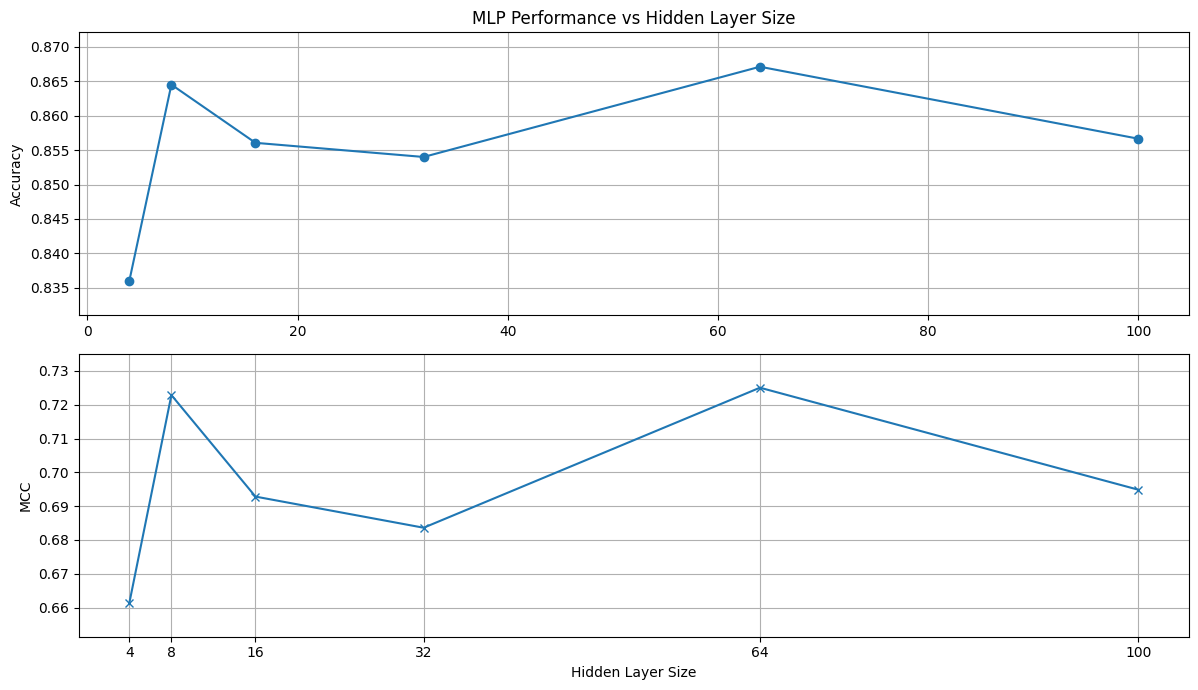

In [ ]:
plt.figure(figsize=(12, 7))

# ==== Plot Accuracy ====
plt.subplot(2, 1, 1)
plt.plot(hidden_layer_sizes_list, mean_acc_mlp, marker='o')
plt.title("MLP Performance vs Hidden Layer Size")
plt.ylabel("Accuracy")
plt.grid(True)
plt.ylim(min(mean_acc_mlp) - 0.005, max(mean_acc_mlp) + 0.005)

# ==== Plot MCC ====
plt.subplot(2, 1, 2)
plt.plot(hidden_layer_sizes_list, mean_mcc_mlp, marker='x')
plt.xlabel("Hidden Layer Size")
plt.ylabel("MCC")
plt.grid(True)
plt.ylim(min(mean_mcc_mlp) - 0.01, max(mean_mcc_mlp) + 0.01)

# Set X-ticks agar sesuai angka
plt.xticks(hidden_layer_sizes_list)

plt.tight_layout()
plt.show()

In [ ]:
!pip install pytorch-tabnet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.5/44.5 kB 2.1 MB/s eta 0:00:00


In [ ]:
import time
from pytorch_tabnet.tab_model import TabNetClassifier
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.metrics import accuracy_score, matthews_corrcoef
import numpy as np
import torch
import pandas as pd # Ensure pandas is imported

# Hyperparameter list
n_d_a_list = [8, 16, 32, 64]

mean_acc_tabnet = []
mean_mcc_tabnet = []

rskf = RepeatedStratifiedKFold(n_splits=5, n_repeats=5, random_state=42)

print("\n===============================")
print("         TABNET EVALUATION")
print("===============================\n")

for dim in n_d_a_list:

    print(f"\n\n======================\n  n_d = n_a = {dim}\n======================")

    acc_all = []
    mcc_all = []
    train_time_all_fold = [] # Renamed to avoid conflict with outer scope
    predict_time_all_fold = [] # Renamed to avoid conflict with outer scope
    fold_counter = 1

    for train_idx, test_idx in rskf.split(X_train, y_train):

        # === Ambil fold ===
        X_train_fold = X_train.iloc[train_idx].copy()
        X_test_fold  = X_train.iloc[test_idx].copy()
        y_train_fold = y_train.iloc[train_idx].values
        y_test_fold  = y_train.iloc[test_idx].values

        # === Feature Selection per fold ===
        selected_features, scores = select_topk_features_MI(X_train_fold, y_train_fold, k=15)

        X_train_fs = X_train_fold[selected_features]
        X_test_fs  = X_test_fold[selected_features]

        # === Scaling per fold ===
        scaler = ModifiedZScoreScaler()
        X_train_scaled = scaler.fit_transform(X_train_fs)
        X_test_scaled  = scaler.transform(X_test_fs)

        # TabNet expects numpy arrays, so convert after scaling if they are DataFrames
        X_train_scaled_tabnet = X_train_scaled.values if isinstance(X_train_scaled, pd.DataFrame) else X_train_scaled
        X_test_scaled_tabnet = X_test_scaled.values if isinstance(X_test_scaled, pd.DataFrame) else X_test_scaled

        # === Model TabNet ===
        model = TabNetClassifier(
            n_d=dim,
            n_a=dim,
            n_steps=5,
            gamma=1.3,
            lambda_sparse=1e-4,
            optimizer_fn=torch.optim.Adam,
            optimizer_params=dict(lr=1e-3),
            verbose=0,
            seed=42 # Added seed for reproducibility
        )

        # === Timing Training ===
        start_train = time.time()
        model.fit(
            X_train_scaled_tabnet, y_train_fold,
            eval_set=[(X_test_scaled_tabnet, y_test_fold)],
            eval_metric=['accuracy'],
            max_epochs=100,
            patience=30
        )
        train_time = time.time() - start_train

        # === Timing Predict ===
        start_pred = time.time()
        y_pred = model.predict(X_test_scaled_tabnet)
        pred_time = time.time() - start_pred

        # === Evaluasi ===
        acc = accuracy_score(y_test_fold, y_pred)
        mcc = matthews_corrcoef(y_test_fold, y_pred)

        acc_all.append(acc)
        mcc_all.append(mcc)
        train_time_all_fold.append(train_time)
        predict_time_all_fold.append(pred_time)

        print(f"\n===== Fold {fold_counter} ====")
        print("Selected features:", list(selected_features))
        print(f"Accuracy: {acc:.5f}")
        print(f"MCC: {mcc:.5f}")
        print(f"Training Time:  {train_time:.5f} sec")
        print(f"Prediksi Time:  {pred_time:.5f} sec")
        fold_counter += 1

    # === Hasil per konfigurasi hidden dimension ===
    mean_acc_tabnet.append(np.mean(acc_all))
    mean_mcc_tabnet.append(np.mean(mcc_all))
    mean_train = np.mean(train_time_all_fold)
    mean_pred = np.mean(predict_time_all_fold)

    print(f"\n>>> RESULT for n_d = n_a = {dim}")
    print(f"Mean Accuracy: {np.mean(acc_all):.5f}")
    print(f"Mean MCC: {np.mean(mcc_all):.5f}")
    print(f"Mean Train Time:    {mean_train:.5f} sec")
    print(f"Mean Predict Time:  {mean_pred:.5f} sec")


         TABNET EVALUATION



  n_d = n_a = 8

Early stopping occurred at epoch 46 with best_epoch = 16 and best_val_0_accuracy = 0.81849


/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)



===== Fold 1 ====
Selected features: ['cbo', 'cyclo', 'wmc', 'lcom', 'lloc', 'E', 'T', 'V', 'B', 'sloc', 'N_hat', 'D', 'N', 'η', 'N2']
Accuracy: 0.81849
MCC: 0.56203
Training Time:  51.44542 sec
Prediksi Time:  0.06827 sec

Early stopping occurred at epoch 39 with best_epoch = 9 and best_val_0_accuracy = 0.81378


/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)



===== Fold 2 ====
Selected features: ['cbo', 'wmc', 'cyclo', 'lcom', 'lloc', 'E', 'T', 'V', 'B', 'sloc', 'N_hat', 'D', 'η', 'blank', 'N2']
Accuracy: 0.81378
MCC: 0.56089
Training Time:  25.82333 sec
Prediksi Time:  0.06321 sec

Early stopping occurred at epoch 40 with best_epoch = 10 and best_val_0_accuracy = 0.81635


...


===== Fold 23 ====
Selected features: ['cbo', 'cyclo', 'wmc', 'lcom', 'lloc', 'T', 'E', 'V', 'B', 'sloc', 'N_hat', 'D', 'η', 'blank', 'N']
Accuracy: 0.88399
MCC: 0.74130
Training Time:  196.58415 sec
Prediksi Time:  0.17377 sec
Stop training because you reached max_epochs = 100 with best_epoch = 98 and best_val_0_accuracy = 0.88356


/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)



===== Fold 24 ====
Selected features: ['cbo', 'wmc', 'cyclo', 'lcom', 'lloc', 'T', 'E', 'V', 'sloc', 'B', 'N_hat', 'D', 'η', 'η2', 'N']
Accuracy: 0.88356
MCC: 0.74412
Training Time:  198.16451 sec
Prediksi Time:  0.18359 sec
Stop training because you reached max_epochs = 100 with best_epoch = 84 and best_val_0_accuracy = 0.88522


/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)



===== Fold 25 ====
Selected features: ['cbo', 'cyclo', 'wmc', 'lcom', 'T', 'E', 'lloc', 'V', 'B', 'sloc', 'N_hat', 'D', 'N', 'blank', 'η']
Accuracy: 0.88522
MCC: 0.75670
Training Time:  196.76582 sec
Prediksi Time:  0.16391 sec

>>> RESULT for n_d = n_a = 64
Mean Accuracy: 0.88489
Mean MCC: 0.74972
Mean Train Time:    184.83941 sec
Mean Predict Time:  0.17847 sec


Itepretasi:

Meskipun konfigurasi n_d = n_a = 64 memiliki waktu training paling tinggi, parameter ini tetap dipilih karena menghasilkan nilai MCC tertinggi yang signifikan pada dataset yang tidak seimbang. Waktu training bukan metrik utama karena proses pelatihan dilakukan secara offline dan jarang, sedangkan kualitas prediksi yang direpresentasikan oleh MCC jauh lebih penting untuk menjamin performa klasifikasi yang adil pada seluruh kelas.

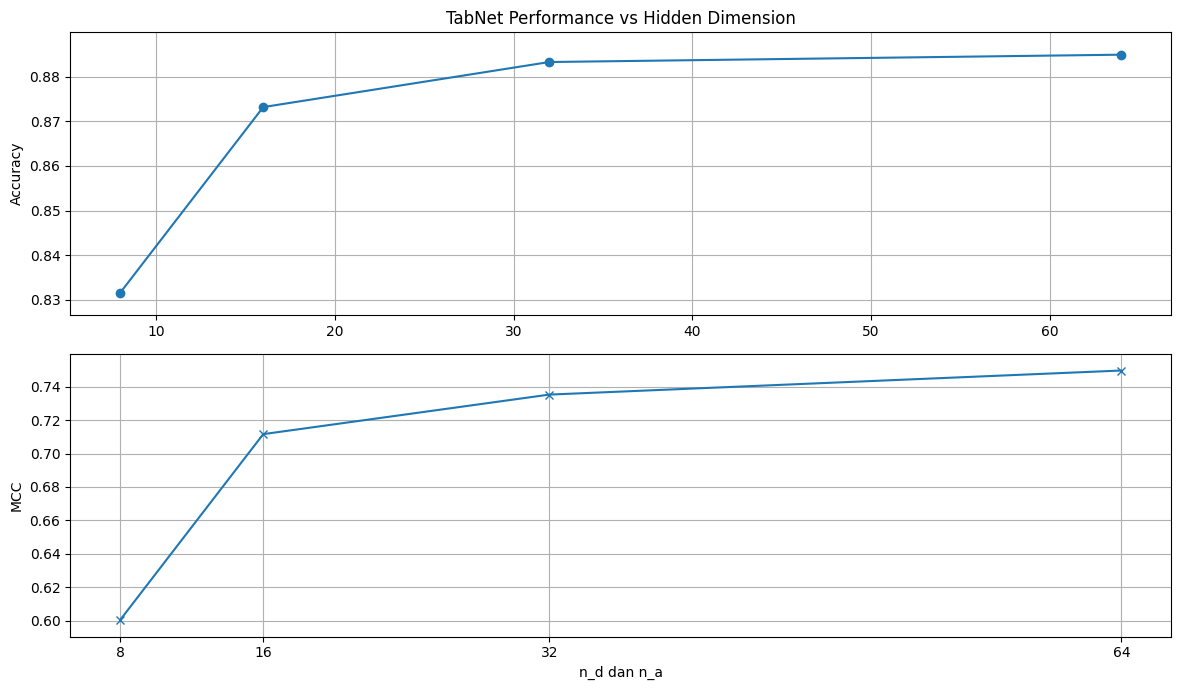

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 7))

# Plot Accuracy
plt.subplot(2, 1, 1)
plt.plot(n_d_a_list, mean_acc_tabnet, marker='o')
plt.title("TabNet Performance vs Hidden Dimension")
plt.ylabel("Accuracy")
plt.grid(True)
plt.ylim(min(mean_acc_tabnet) - 0.005, max(mean_acc_tabnet) + 0.005)

# Plot MCC
plt.subplot(2, 1, 2)
plt.plot(n_d_a_list, mean_mcc_tabnet, marker='x')
plt.xlabel("n_d dan n_a")
plt.ylabel("MCC")
plt.grid(True)
plt.ylim(min(mean_mcc_tabnet) - 0.01, max(mean_mcc_tabnet) + 0.01)

# Set X-ticks agar sesuai angka
plt.xticks(n_d_a_list)

plt.tight_layout()
plt.show()